In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 合并前统一检查数据质量

In [2]:
# === 通用数据检查函数 ===
def check_data(df, name):
    print(f"\n=== 检查数据集: {name} ===")
    print(f"数据集大小: {df.shape}")
    print("\n数据类型:")
    print(df.dtypes)
    print("\n空值统计:")
    print(df.isnull().sum())
    print("\n前 2 行数据:")
    print(df.head(2))

In [3]:
# === 读取数据集 ===
# 1. 迁移流数据
migration_path = '../data/processed/migration_flow_cleaned.csv'
migration_df = pd.read_csv(migration_path)
check_data(migration_df, "迁移流数据")


=== 检查数据集: 迁移流数据 ===
数据集大小: (1563154, 7)

数据类型:
origin_iso3          object
destination_iso3     object
migration_date       object
year                  int64
month                 int64
flow                  int64
log_flow            float64
dtype: object

空值统计:
origin_iso3         0
destination_iso3    0
migration_date      0
year                0
month               0
flow                0
log_flow            0
dtype: int64

前 2 行数据:
  origin_iso3 destination_iso3 migration_date  year  month  flow  log_flow
0         AND              ARE     2019-01-01  2019      1    12  2.564949
1         AND              ARE     2019-02-01  2019      2     2  1.098612


In [4]:
# 2. 气候数据
spei_path = '../data/processed/spei_clean.csv'
spei_df = pd.read_csv(spei_path)

check_data(spei_df, "气候数据")


=== 检查数据集: 气候数据 ===
数据集大小: (8928, 8)

数据类型:
spei_iso3     object
spei         float64
spei_date     object
year           int64
month          int64
spei_lag1    float64
spei_lag2    float64
spei_lag3    float64
dtype: object

空值统计:
spei_iso3    0
spei         0
spei_date    0
year         0
month        0
spei_lag1    0
spei_lag2    0
spei_lag3    0
dtype: int64

前 2 行数据:
  spei_iso3      spei   spei_date  year  month  spei_lag1  spei_lag2  \
0       AFG -0.101823  2019-01-16  2019      1  -0.092170   0.173375   
1       ALA -0.584555  2019-01-16  2019      1  -0.591903  -0.573946   

   spei_lag3  
0  -0.499876  
1  -0.568361  


In [5]:
# 3. 市场准入数据
MA_path = '../data/processed/MA_clean.csv'
MA_df = pd.read_csv(MA_path)
check_data(MA_df, "市场准入数据")


=== 检查数据集: 市场准入数据 ===
数据集大小: (796, 3)

数据类型:
iso3     object
year      int64
MA      float64
dtype: object

空值统计:
iso3    0
year    0
MA      0
dtype: int64

前 2 行数据:
  iso3  year         MA
0  FRO  2019  19.139440
1  VUT  2019  17.405946


In [6]:
# 4：边界摩擦数据
border_path = '../data/processed/BF_ew_clean.csv'
border_df = pd.read_csv(border_path)
check_data(border_df, "边界摩擦数据")


=== 检查数据集: 边界摩擦数据 ===
数据集大小: (50176, 6)

数据类型:
iso_o               object
iso_d               object
contig               int64
comlang_off          int64
colony               int64
border_friction    float64
dtype: object

空值统计:
iso_o              0
iso_d              0
contig             0
comlang_off        0
colony             0
border_friction    0
dtype: int64

前 2 行数据:
  iso_o iso_d  contig  comlang_off  colony  border_friction
0   ABW   ABW       0            0       0              1.0
1   ABW   AFG       0            0       0              1.0


In [7]:
# 5.1 控制变量——地理距离
control_dist_path = '../data/processed/control_distwces.csv'
control_dist_df = pd.read_csv(control_dist_path)
check_data(control_dist_df, "控制变量 地理距离")



=== 检查数据集: 控制变量 地理距离 ===
数据集大小: (50176, 3)

数据类型:
origin_iso3          object
destination_iso3     object
control_distwces    float64
dtype: object

空值统计:
origin_iso3         0
destination_iso3    0
control_distwces    0
dtype: int64

前 2 行数据:
  origin_iso3 destination_iso3  control_distwces
0         ABW              ABW          3.137546
1         ABW              AFG          9.485421


In [8]:
# 5.2：控制变量 政治稳定
control_political_stability_path = '../data/processed/control_political_stability.csv'
control_political_stability_df = pd.read_csv(control_political_stability_path)
check_data(control_political_stability_df, "控制变量 政治稳定")


=== 检查数据集: 控制变量 政治稳定 ===
数据集大小: (856, 3)

数据类型:
iso3                    object
year                     int64
political_stability    float64
dtype: object

空值统计:
iso3                   0
year                   0
political_stability    4
dtype: int64

前 2 行数据:
  iso3  year  political_stability
0  AFG  2019            -2.652540
1  ALB  2019             0.110105


In [9]:
# 5.3：控制变量 WDI
control_wdi_path = '../data/processed/control_wdi_variables.csv'
control_wdi_df = pd.read_csv(control_wdi_path)
check_data(control_wdi_df, "控制变量 WDI")


=== 检查数据集: 控制变量 WDI ===
数据集大小: (1064, 6)

数据类型:
iso3       object
year        int64
gdp_pc    float64
pop       float64
urban     float64
unemp     float64
dtype: object

空值统计:
iso3        0
year        0
gdp_pc     31
pop         4
urban      12
unemp     124
dtype: int64

前 2 行数据:
  iso3  year     gdp_pc        pop   urban  unemp
0  ABW  2019  10.311687  11.600964  43.546    NaN
1  ABW  2020  10.344841  11.595307  43.697    NaN


### 开始合并

#### 第 1 步：基础表（迁移流）

In [10]:
migration_path = '../data/processed/migration_flow_cleaned.csv'
migration_df = pd.read_csv(migration_path)

# 重命名列
migration_df = migration_df.rename(columns={
    'o_iso3': 'origin_iso3',
    'd_iso3': 'destination_iso3',
    'migration_date': 'migration_date',
    'year': 'year',
    'month': 'month',
    'flow': 'flow',
    'log_flow': 'log_flow'
})
print("基础表（迁移流）已加载，数据大小:", migration_df.shape)
print(migration_df.head())

基础表（迁移流）已加载，数据大小: (1563154, 7)
  origin_iso3 destination_iso3 migration_date  year  month  flow  log_flow
0         AND              ARE     2019-01-01  2019      1    12  2.564949
1         AND              ARE     2019-02-01  2019      2     2  1.098612
2         AND              ARE     2019-03-01  2019      3     1  0.693147
3         AND              ARE     2019-04-01  2019      4     7  2.079442
4         AND              ARE     2019-05-01  2019      5     0  0.000000


#### 第 2 步：拼接 origin-only 数据

In [11]:
# SPEI 干旱指数
spei_df = pd.read_csv(spei_path).rename(columns={'spei_iso3': 'origin_iso3', 'spei': 'o_spei'})
migration_df = migration_df.merge(spei_df, on=['origin_iso3', 'year', 'month'], how='left')

print("完成 spei 数据拼接，数据大小:", migration_df.shape)
print(migration_df.head())

完成 spei 数据拼接，数据大小: (1563154, 12)
  origin_iso3 destination_iso3 migration_date  year  month  flow  log_flow  \
0         AND              ARE     2019-01-01  2019      1    12  2.564949   
1         AND              ARE     2019-02-01  2019      2     2  1.098612   
2         AND              ARE     2019-03-01  2019      3     1  0.693147   
3         AND              ARE     2019-04-01  2019      4     7  2.079442   
4         AND              ARE     2019-05-01  2019      5     0  0.000000   

   o_spei spei_date  spei_lag1  spei_lag2  spei_lag3  
0     NaN       NaN        NaN        NaN        NaN  
1     NaN       NaN        NaN        NaN        NaN  
2     NaN       NaN        NaN        NaN        NaN  
3     NaN       NaN        NaN        NaN        NaN  
4     NaN       NaN        NaN        NaN        NaN  


In [12]:
# Market Access
ma_path = '../data/processed/MA_clean.csv'
ma_df = pd.read_csv(ma_path).rename(columns={'iso3': 'origin_iso3', 'MA': 'o_MA'})
migration_df = migration_df.merge(ma_df, on=['origin_iso3', 'year'], how='left')

print("完成 MA 数据拼接，数据大小:", migration_df.shape)
print(migration_df.head())

完成 MA 数据拼接，数据大小: (1563154, 13)
  origin_iso3 destination_iso3 migration_date  year  month  flow  log_flow  \
0         AND              ARE     2019-01-01  2019      1    12  2.564949   
1         AND              ARE     2019-02-01  2019      2     2  1.098612   
2         AND              ARE     2019-03-01  2019      3     1  0.693147   
3         AND              ARE     2019-04-01  2019      4     7  2.079442   
4         AND              ARE     2019-05-01  2019      5     0  0.000000   

   o_spei spei_date  spei_lag1  spei_lag2  spei_lag3      o_MA  
0     NaN       NaN        NaN        NaN        NaN  19.87853  
1     NaN       NaN        NaN        NaN        NaN  19.87853  
2     NaN       NaN        NaN        NaN        NaN  19.87853  
3     NaN       NaN        NaN        NaN        NaN  19.87853  
4     NaN       NaN        NaN        NaN        NaN  19.87853  


In [13]:
# WDI origin 控制变量
wdi_origin_path = '../data/processed/control_wdi_variables.csv'
wdi_origin_df = pd.read_csv(wdi_origin_path).rename(columns={
    'iso3': 'origin_iso3',
    'gdp_pc': 'o_gdp_pc',
    'pop': 'o_pop',
    'urban': 'o_urban',
    'unemp': 'o_unemp'
})
migration_df = migration_df.merge(wdi_origin_df, on=['origin_iso3', 'year'], how='left')

print("完成 WDI origin 数据拼接，数据大小:", migration_df.shape)
print(migration_df.head())

完成 WDI origin 数据拼接，数据大小: (1563154, 17)
  origin_iso3 destination_iso3 migration_date  year  month  flow  log_flow  \
0         AND              ARE     2019-01-01  2019      1    12  2.564949   
1         AND              ARE     2019-02-01  2019      2     2  1.098612   
2         AND              ARE     2019-03-01  2019      3     1  0.693147   
3         AND              ARE     2019-04-01  2019      4     7  2.079442   
4         AND              ARE     2019-05-01  2019      5     0  0.000000   

   o_spei spei_date  spei_lag1  spei_lag2  spei_lag3      o_MA   o_gdp_pc  \
0     NaN       NaN        NaN        NaN        NaN  19.87853  10.664755   
1     NaN       NaN        NaN        NaN        NaN  19.87853  10.664755   
2     NaN       NaN        NaN        NaN        NaN  19.87853  10.664755   
3     NaN       NaN        NaN        NaN        NaN  19.87853  10.664755   
4     NaN       NaN        NaN        NaN        NaN  19.87853  10.664755   

       o_pop  o_urban  o_unem

In [14]:
# 政治稳定（origin）
political_stability_path = '../data/processed/control_political_stability.csv'
political_stability_df = pd.read_csv(political_stability_path).rename(columns={'iso3': 'origin_iso3', 'political_stability': 'o_political_stability'})
migration_df = migration_df.merge(political_stability_df, on=['origin_iso3', 'year'], how='left')

print("完成 origin-only 数据拼接，数据大小:", migration_df.shape)

完成 origin-only 数据拼接，数据大小: (1563154, 18)


In [15]:
check_data(migration_df, "origin-only 数据")


=== 检查数据集: origin-only 数据 ===
数据集大小: (1563154, 18)

数据类型:
origin_iso3               object
destination_iso3          object
migration_date            object
year                       int64
month                      int64
flow                       int64
log_flow                 float64
o_spei                   float64
spei_date                 object
spei_lag1                float64
spei_lag2                float64
spei_lag3                float64
o_MA                     float64
o_gdp_pc                 float64
o_pop                    float64
o_urban                  float64
o_unemp                  float64
o_political_stability    float64
dtype: object

空值统计:
origin_iso3                   0
destination_iso3              0
migration_date                0
year                          0
month                         0
flow                          0
log_flow                      0
o_spei                   120960
spei_date                120960
spei_lag1                120960
spei_l

#### 第 3 步：拼接 destination-only 数据 

In [16]:
# WDI destination 控制变量
wdi_destination_df = pd.read_csv(wdi_origin_path).rename(columns={
    'iso3': 'destination_iso3',
    'gdp_pc': 'd_gdp_pc',
    'pop': 'd_pop',
    'urban': 'd_urban',
    'unemp': 'd_unemp'
})
migration_df = migration_df.merge(wdi_destination_df, on=['destination_iso3', 'year'], how='left')

print("完成 WDI destination 数据拼接，数据大小:", migration_df.shape)
print(migration_df.head())

完成 WDI destination 数据拼接，数据大小: (1563154, 22)
  origin_iso3 destination_iso3 migration_date  year  month  flow  log_flow  \
0         AND              ARE     2019-01-01  2019      1    12  2.564949   
1         AND              ARE     2019-02-01  2019      2     2  1.098612   
2         AND              ARE     2019-03-01  2019      3     1  0.693147   
3         AND              ARE     2019-04-01  2019      4     7  2.079442   
4         AND              ARE     2019-05-01  2019      5     0  0.000000   

   o_spei spei_date  spei_lag1  ...      o_MA   o_gdp_pc      o_pop  o_urban  \
0     NaN       NaN        NaN  ...  19.87853  10.664755  11.244706   87.984   
1     NaN       NaN        NaN  ...  19.87853  10.664755  11.244706   87.984   
2     NaN       NaN        NaN  ...  19.87853  10.664755  11.244706   87.984   
3     NaN       NaN        NaN  ...  19.87853  10.664755  11.244706   87.984   
4     NaN       NaN        NaN  ...  19.87853  10.664755  11.244706   87.984   

   o_u

In [17]:
# 政治稳定（destination）
political_stability_destination_df = political_stability_df.rename(columns={
    'origin_iso3': 'destination_iso3',
    'o_political_stability': 'd_political_stability'
})
migration_df = migration_df.merge(political_stability_destination_df, on=['destination_iso3', 'year'], how='left')

print("完成 政治稳定 destination 数据拼接，数据大小:", migration_df.shape)
print(migration_df.head())

完成 政治稳定 destination 数据拼接，数据大小: (1563154, 23)
  origin_iso3 destination_iso3 migration_date  year  month  flow  log_flow  \
0         AND              ARE     2019-01-01  2019      1    12  2.564949   
1         AND              ARE     2019-02-01  2019      2     2  1.098612   
2         AND              ARE     2019-03-01  2019      3     1  0.693147   
3         AND              ARE     2019-04-01  2019      4     7  2.079442   
4         AND              ARE     2019-05-01  2019      5     0  0.000000   

   o_spei spei_date  spei_lag1  ...   o_gdp_pc      o_pop  o_urban  o_unemp  \
0     NaN       NaN        NaN  ...  10.664755  11.244706   87.984      NaN   
1     NaN       NaN        NaN  ...  10.664755  11.244706   87.984      NaN   
2     NaN       NaN        NaN  ...  10.664755  11.244706   87.984      NaN   
3     NaN       NaN        NaN  ...  10.664755  11.244706   87.984      NaN   
4     NaN       NaN        NaN  ...  10.664755  11.244706   87.984      NaN   

   o_politi

In [18]:
check_data(migration_df, "destination-only 数据")


=== 检查数据集: destination-only 数据 ===
数据集大小: (1563154, 23)

数据类型:
origin_iso3               object
destination_iso3          object
migration_date            object
year                       int64
month                      int64
flow                       int64
log_flow                 float64
o_spei                   float64
spei_date                 object
spei_lag1                float64
spei_lag2                float64
spei_lag3                float64
o_MA                     float64
o_gdp_pc                 float64
o_pop                    float64
o_urban                  float64
o_unemp                  float64
o_political_stability    float64
d_gdp_pc                 float64
d_pop                    float64
d_urban                  float64
d_unemp                  float64
d_political_stability    float64
dtype: object

空值统计:
origin_iso3                   0
destination_iso3              0
migration_date                0
year                          0
month                       

#### 第 4 步：拼接双边（origin × destination）变量

In [19]:
# 边境摩擦
border_path = '../data/processed/BF_ew_clean.csv'
border_df = pd.read_csv(border_path).rename(columns={'iso_o': 'origin_iso3', 'iso_d': 'destination_iso3', 'border_friction': 'border_friction_ij'})

# 只保留需要的列
border_df = border_df[['origin_iso3', 'destination_iso3', 'border_friction_ij']]

# 合并到主表
migration_df = migration_df.merge(border_df, on=['origin_iso3', 'destination_iso3'], how='left')

print("完成边境摩擦数据拼接，数据大小:", migration_df.shape)
print(migration_df.head())


完成边境摩擦数据拼接，数据大小: (1563154, 24)
  origin_iso3 destination_iso3 migration_date  year  month  flow  log_flow  \
0         AND              ARE     2019-01-01  2019      1    12  2.564949   
1         AND              ARE     2019-02-01  2019      2     2  1.098612   
2         AND              ARE     2019-03-01  2019      3     1  0.693147   
3         AND              ARE     2019-04-01  2019      4     7  2.079442   
4         AND              ARE     2019-05-01  2019      5     0  0.000000   

   o_spei spei_date  spei_lag1  ...      o_pop  o_urban  o_unemp  \
0     NaN       NaN        NaN  ...  11.244706   87.984      NaN   
1     NaN       NaN        NaN  ...  11.244706   87.984      NaN   
2     NaN       NaN        NaN  ...  11.244706   87.984      NaN   
3     NaN       NaN        NaN  ...  11.244706   87.984      NaN   
4     NaN       NaN        NaN  ...  11.244706   87.984      NaN   

   o_political_stability   d_gdp_pc      d_pop  d_urban  d_unemp  \
0                    Na

In [20]:
# 地理距离
control_dist_path = '../data/processed/control_distwces.csv'
migration_df = migration_df.merge(control_dist_df, on=['origin_iso3', 'destination_iso3'], how='left')

print("完成双边变量拼接，数据大小:", migration_df.shape)
print(migration_df.head())

完成双边变量拼接，数据大小: (1563154, 25)
  origin_iso3 destination_iso3 migration_date  year  month  flow  log_flow  \
0         AND              ARE     2019-01-01  2019      1    12  2.564949   
1         AND              ARE     2019-02-01  2019      2     2  1.098612   
2         AND              ARE     2019-03-01  2019      3     1  0.693147   
3         AND              ARE     2019-04-01  2019      4     7  2.079442   
4         AND              ARE     2019-05-01  2019      5     0  0.000000   

   o_spei spei_date  spei_lag1  ...  o_urban  o_unemp  o_political_stability  \
0     NaN       NaN        NaN  ...   87.984      NaN                    NaN   
1     NaN       NaN        NaN  ...   87.984      NaN                    NaN   
2     NaN       NaN        NaN  ...   87.984      NaN                    NaN   
3     NaN       NaN        NaN  ...   87.984      NaN                    NaN   
4     NaN       NaN        NaN  ...   87.984      NaN                    NaN   

    d_gdp_pc      d_p

In [21]:
check_data(migration_df, "最终数据")


=== 检查数据集: 最终数据 ===
数据集大小: (1563154, 25)

数据类型:
origin_iso3               object
destination_iso3          object
migration_date            object
year                       int64
month                      int64
flow                       int64
log_flow                 float64
o_spei                   float64
spei_date                 object
spei_lag1                float64
spei_lag2                float64
spei_lag3                float64
o_MA                     float64
o_gdp_pc                 float64
o_pop                    float64
o_urban                  float64
o_unemp                  float64
o_political_stability    float64
d_gdp_pc                 float64
d_pop                    float64
d_urban                  float64
d_unemp                  float64
d_political_stability    float64
border_friction_ij       float64
control_distwces         float64
dtype: object

空值统计:
origin_iso3                   0
destination_iso3              0
migration_date                0
year     

#### 第五步： 输出合并结果

In [22]:
# # === 保存最终合并结果 ===
# output_path = '../data/processed/merged_origin_dataset.csv'
# migration_df.to_csv(output_path, index=False)
# print(f"最终合并数据已保存到: {output_path}")

### 查看缺失模式

In [23]:
# === 1. 总体缺失比例 ===
total_missing = migration_df.isna().mean().mean() * 100
print(f"=== 数据集总体缺失比例：{total_missing:.2f}% ===")

# === 2. 各变量缺失比例 ===
missing_summary = migration_df.isna().mean().sort_values(ascending=False) * 100
print("=== 各变量缺失比例（%） ===")
display(missing_summary)

=== 数据集总体缺失比例：3.13% ===
=== 各变量缺失比例（%） ===


o_spei                   7.738201
spei_date                7.738201
spei_lag3                7.738201
spei_lag2                7.738201
spei_lag1                7.738201
border_friction_ij       7.600531
control_distwces         7.600531
o_MA                     4.413129
o_unemp                  3.313301
d_unemp                  3.313301
d_political_stability    2.760573
o_political_stability    2.758014
o_gdp_pc                 2.210915
d_gdp_pc                 2.210915
d_urban                  1.102387
o_urban                  1.102387
o_pop                    0.552729
d_pop                    0.552729
flow                     0.000000
year                     0.000000
log_flow                 0.000000
migration_date           0.000000
destination_iso3         0.000000
origin_iso3              0.000000
month                    0.000000
dtype: float64

#### 删除所有有任何缺失值的行 migration_df_cleaned

In [24]:
# === 删除缺失值 ===
# 删除包含任何空值的行
migration_df_cleaned = migration_df.dropna()

#### 样本量与覆盖范围

In [25]:
# 1. 基本信息对比
print(f"删除前数据大小: {migration_df.shape}")
print(f"删除后数据大小: {migration_df_cleaned.shape}")
print(f"删除了 {migration_df.shape[0] - migration_df_cleaned.shape[0]:,} 行 ({((migration_df.shape[0] - migration_df_cleaned.shape[0])/migration_df.shape[0]*100):.1f}%)")

删除前数据大小: (1563154, 25)
删除后数据大小: (1250426, 25)
删除了 312,728 行 (20.0%)


In [26]:
# 2. 检查删除前的缺失值模式
print("\n=== 删除前各变量缺失值情况 ===")
missing_before = migration_df.isnull().sum()
missing_pct_before = (missing_before / len(migration_df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing_Count': missing_before,
    'Missing_Percentage': missing_pct_before
}).sort_values('Missing_Percentage', ascending=False)
print(missing_summary[missing_summary['Missing_Count'] > 0])


=== 删除前各变量缺失值情况 ===
                       Missing_Count  Missing_Percentage
o_spei                        120960                7.74
spei_date                     120960                7.74
spei_lag3                     120960                7.74
spei_lag2                     120960                7.74
spei_lag1                     120960                7.74
border_friction_ij            118808                7.60
control_distwces              118808                7.60
o_MA                           68984                4.41
o_unemp                        51792                3.31
d_unemp                        51792                3.31
d_political_stability          43152                2.76
o_political_stability          43112                2.76
o_gdp_pc                       34560                2.21
d_gdp_pc                       34560                2.21
d_urban                        17232                1.10
o_urban                        17232                1.10
o_pop     

In [27]:
# 3. 核心变量的缺失情况
core_vars = ['log_flow', 'spei_lag1', 'o_MA', 'border_friction_ij']
print(f"\n=== 核心变量缺失情况 ===")
for var in core_vars:
    missing = migration_df[var].isnull().sum()
    pct = missing / len(migration_df) * 100
    print(f"{var}: {missing:,} ({pct:.2f}%)")

# 4. 检查删除后是否还有缺失值
print(f"\n=== 删除后缺失值检查 ===")
remaining_missing = migration_df_cleaned.isnull().sum().sum()
print(f"剩余缺失值总数: {remaining_missing}")
if remaining_missing > 0:
    print("各变量剩余缺失值:")
    print(migration_df_cleaned.isnull().sum()[migration_df_cleaned.isnull().sum() > 0])



=== 核心变量缺失情况 ===
log_flow: 0 (0.00%)
spei_lag1: 120,960 (7.74%)
o_MA: 68,984 (4.41%)
border_friction_ij: 118,808 (7.60%)

=== 删除后缺失值检查 ===
剩余缺失值总数: 0


In [28]:
# 5. 面板结构完整性
print(f"\n=== 面板结构检查 ===")
# 检查国家对数量
unique_pairs_before = migration_df[['origin_iso3', 'destination_iso3']].drop_duplicates().shape[0]
unique_pairs_after = migration_df_cleaned[['origin_iso3', 'destination_iso3']].drop_duplicates().shape[0]
print(f"删除前国家对数量: {unique_pairs_before}")
print(f"删除后国家对数量: {unique_pairs_after}")
print(f"丢失国家对: {unique_pairs_before - unique_pairs_after}")


=== 面板结构检查 ===
删除前国家对数量: 32568
删除后国家对数量: 26052
丢失国家对: 6516


In [29]:
# 检查时间覆盖
time_coverage_before = migration_df.groupby(['year', 'month']).size().reset_index(name='count')
time_coverage_after = migration_df_cleaned.groupby(['year', 'month']).size().reset_index(name='count')
print(f"\n时间覆盖情况:")
print(f"删除前时间点数: {len(time_coverage_before)}")
print(f"删除后时间点数: {len(time_coverage_after)}")


时间覆盖情况:
删除前时间点数: 48
删除后时间点数: 48


In [30]:
# 6. 检查数据分布变化
print(f"\n=== 关键变量分布对比 ===")
key_vars = ['log_flow', 'spei_lag1', 'o_MA', 'border_friction_ij']
for var in key_vars:
    print(f"\n{var}:")
    print(f"删除前: mean={migration_df[var].mean():.3f}, std={migration_df[var].std():.3f}")
    print(f"删除后: mean={migration_df_cleaned[var].mean():.3f}, std={migration_df_cleaned[var].std():.3f}")


=== 关键变量分布对比 ===

log_flow:
删除前: mean=1.612, std=1.751
删除后: mean=1.705, std=1.800

spei_lag1:
删除前: mean=-0.267, std=0.864
删除后: mean=-0.265, std=0.872

o_MA:
删除前: mean=18.611, std=0.792
删除后: mean=18.617, std=0.790

border_friction_ij:
删除前: mean=0.942, std=0.140
删除后: mean=0.944, std=0.140


In [31]:
# 7. 检查国家覆盖情况
print(f"\n=== 国家覆盖检查 ===")
origins_before = migration_df['origin_iso3'].nunique()
origins_after = migration_df_cleaned['origin_iso3'].nunique()
dests_before = migration_df['destination_iso3'].nunique()
dests_after = migration_df_cleaned['destination_iso3'].nunique()

print(f"起源国: {origins_before} → {origins_after} (丢失 {origins_before - origins_after})")
print(f"目的国: {dests_before} → {dests_after} (丢失 {dests_before - dests_after})")

# 找出丢失的国家
lost_origins = set(migration_df['origin_iso3'].unique()) - set(migration_df_cleaned['origin_iso3'].unique())
lost_dests = set(migration_df['destination_iso3'].unique()) - set(migration_df_cleaned['destination_iso3'].unique())
if lost_origins:
    print(f"丢失的起源国: {sorted(lost_origins)}")
if lost_dests:
    print(f"丢失的目的国: {sorted(lost_dests)}")


=== 国家覆盖检查 ===
起源国: 181 → 157 (丢失 24)
目的国: 181 → 167 (丢失 14)
丢失的起源国: ['AND', 'BHR', 'BRB', 'COD', 'ERI', 'FSM', 'GRD', 'HKG', 'KIR', 'LCA', 'MAC', 'MDV', 'MLT', 'MNE', 'ROU', 'SGP', 'SRB', 'SSD', 'STP', 'TLS', 'TON', 'TWN', 'VEN', 'XKX']
丢失的目的国: ['AND', 'COD', 'ERI', 'FSM', 'GRD', 'KIR', 'MNE', 'ROU', 'SRB', 'SSD', 'TLS', 'TWN', 'VEN', 'XKX']


In [32]:
# 8. 每个国家对的观测数量分布
print(f"\n=== 国家对观测数量分布 ===")
pair_counts = migration_df_cleaned.groupby(['origin_iso3', 'destination_iso3']).size()
print(f"最小观测数: {pair_counts.min()}")
print(f"最大观测数: {pair_counts.max()}")
print(f"平均观测数: {pair_counts.mean():.1f}")
print(f"中位数观测数: {pair_counts.median()}")

# 观测数少于48个月的国家对
incomplete_pairs = pair_counts[pair_counts < 48]
print(f"观测不完整的国家对: {len(incomplete_pairs)} ({len(incomplete_pairs)/len(pair_counts)*100:.1f}%)")



=== 国家对观测数量分布 ===
最小观测数: 22
最大观测数: 48
平均观测数: 48.0
中位数观测数: 48.0
观测不完整的国家对: 9 (0.0%)


### 选择性填充非核心变量

In [33]:
# 改进的数据恢复策略
def improved_data_recovery():
    """更智能的数据恢复策略"""
    
    df = migration_df.copy()
    print("=== 改进的数据恢复策略 ===")
    
    # 1. 分析缺失模式
    print("步骤1: 分析缺失模式")
    missing_analysis = df.isnull().sum()
    print("主要缺失变量:")
    for var in missing_analysis[missing_analysis > 0].sort_values(ascending=False).head(10).index:
        missing_pct = missing_analysis[var] / len(df) * 100
        print(f"  {var}: {missing_analysis[var]:,} ({missing_pct:.1f}%)")
    
    # 2. 核心变量筛选（必须完整）
    core_vars = ['log_flow', 'spei_lag1', 'o_MA', 'border_friction_ij']
    print(f"\n步骤2: 核心变量筛选")
    before = len(df)
    df = df.dropna(subset=core_vars)
    after = len(df)
    print(f"数据量: {before:,} → {after:,} (-{before-after:,})")
    
    # 3. 按变量重要性分层填充
    print(f"\n步骤3: 分层填充策略")
    
    # 3a. 经济变量：使用多种填充方法
    economic_vars = ['o_gdp_pc', 'd_gdp_pc', 'o_unemp', 'd_unemp']
    for var in economic_vars:
        missing_before = df[var].isnull().sum()
        
        # 方法1: 按国家组时间序列填充
        df[var] = df.groupby(['origin_iso3', 'destination_iso3'])[var].transform(
            lambda x: x.fillna(method='ffill').fillna(method='bfill')
        )
        
        # 方法2: 如果仍有缺失，按单个国家填充
        if var.startswith('o_'):
            df[var] = df.groupby('origin_iso3')[var].transform(
                lambda x: x.fillna(x.mean())
            )
        else:
            df[var] = df.groupby('destination_iso3')[var].transform(
                lambda x: x.fillna(x.mean())
            )
        
        # 方法3: 全局中位数填充剩余缺失
        df[var] = df[var].fillna(df[var].median())
        
        missing_after = df[var].isnull().sum()
        print(f"  {var}: {missing_before:,} → {missing_after:,}")
    
    # 3b. 人口变量：线性插值
    demo_vars = ['o_pop', 'd_pop', 'o_urban', 'd_urban']
    for var in demo_vars:
        missing_before = df[var].isnull().sum()
        
        # 按国家时间序列插值
        country_col = 'origin_iso3' if var.startswith('o_') else 'destination_iso3'
        df[var] = df.groupby(country_col)[var].transform(
            lambda x: x.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
        )
        
        # 全局填充剩余
        df[var] = df[var].fillna(df[var].median())
        
        missing_after = df[var].isnull().sum()
        print(f"  {var}: {missing_before:,} → {missing_after:,}")
    
    # 3c. 政治变量：长期稳定假设
    political_vars = ['o_political_stability', 'd_political_stability']
    for var in political_vars:
        missing_before = df[var].isnull().sum()
        
        # 政治稳定性年度变化小，用国家均值
        country_col = 'origin_iso3' if var.startswith('o_') else 'destination_iso3'
        df[var] = df.groupby(country_col)[var].transform(
            lambda x: x.fillna(x.mean())
        )
        
        # 全局中位数
        df[var] = df[var].fillna(df[var].median())
        
        missing_after = df[var].isnull().sum()
        print(f"  {var}: {missing_before:,} → {missing_after:,}")
    
    # 4. 创建缺失值指示器
    print(f"\n步骤4: 创建缺失值指示器")
    important_vars = economic_vars + demo_vars + political_vars
    for var in important_vars:
        indicator_name = f"{var}_was_missing"
        df[indicator_name] = migration_df[var].isnull().astype(int)
        missing_count = df[indicator_name].sum()
        if missing_count > 0:
            print(f"  {indicator_name}: {missing_count:,} 个观测被标记")
    
    # 5. 最终检查
    final_missing = df.isnull().sum().sum()
    print(f"\n步骤5: 最终检查")
    if final_missing > 0:
        print(f"剩余缺失值: {final_missing}")
        print(df.isnull().sum()[df.isnull().sum() > 0])
        # 删除仍有缺失的行
        df = df.dropna()
    else:
        print("无剩余缺失值!")
    
    return df

def compare_strategies(original, cleaned, recovered):
    """对比不同策略的效果"""
    print("\n=== 策略对比分析 ===")
    
    strategies = {
        "原始数据": original,
        "完全删除": cleaned, 
        "改进恢复": recovered
    }
    
    print(f"{'策略':<12} {'行数':<12} {'保留率':<8} {'国家对':<8}")
    print("-" * 45)
    
    for name, df in strategies.items():
        rows = len(df)
        retention = rows / len(original) * 100
        country_pairs = df.groupby(['origin_iso3', 'destination_iso3']).size().shape[0]
        print(f"{name:<12} {rows:<12,} {retention:<7.1f}% {country_pairs:<8,}")
    
    # 检查关键变量分布
    print(f"\n=== 关键变量统计对比 ===")
    key_vars = ['log_flow', 'spei_lag1', 'o_MA']
    
    for var in key_vars:
        print(f"\n{var}:")
        for name, df in strategies.items():
            if name == "原始数据":
                continue
            mean_val = df[var].mean()
            std_val = df[var].std()
            print(f"  {name}: 均值={mean_val:.3f}, 标准差={std_val:.3f}")

# 使用示例
migration_df_improved = improved_data_recovery()
compare_strategies(migration_df, migration_df_cleaned, migration_df_improved)

=== 改进的数据恢复策略 ===
步骤1: 分析缺失模式
主要缺失变量:
  o_spei: 120,960 (7.7%)
  spei_date: 120,960 (7.7%)
  spei_lag1: 120,960 (7.7%)
  spei_lag2: 120,960 (7.7%)
  spei_lag3: 120,960 (7.7%)
  border_friction_ij: 118,808 (7.6%)
  control_distwces: 118,808 (7.6%)
  o_MA: 68,984 (4.4%)
  o_unemp: 51,792 (3.3%)
  d_unemp: 51,792 (3.3%)

步骤2: 核心变量筛选
数据量: 1,563,154 → 1,319,786 (-243,368)

步骤3: 分层填充策略


C:\Users\cmy\AppData\Local\Temp\ipykernel_32976\1253694387.py:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill')


  o_gdp_pc: 16,608 → 0


C:\Users\cmy\AppData\Local\Temp\ipykernel_32976\1253694387.py:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill')


  d_gdp_pc: 22,800 → 0


...

  d_pop: 7,632 → 0


C:\Users\cmy\AppData\Local\Temp\ipykernel_32976\1253694387.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


  o_urban: 0 → 0


C:\Users\cmy\AppData\Local\Temp\ipykernel_32976\1253694387.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


  d_urban: 7,632 → 0
  o_political_stability: 0 → 0
  d_political_stability: 7,632 → 0

步骤4: 创建缺失值指示器
  o_gdp_pc_was_missing: 16,608 个观测被标记
  d_gdp_pc_was_missing: 22,800 个观测被标记
  d_unemp_was_missing: 38,160 个观测被标记
  d_pop_was_missing: 7,632 个观测被标记
  d_urban_was_missing: 7,632 个观测被标记
  d_political_stability_was_missing: 7,632 个观测被标记

步骤5: 最终检查
无剩余缺失值!

=== 策略对比分析 ===
策略           行数           保留率      国家对     
---------------------------------------------
原始数据         1,563,154    100.0  % 32,568  
完全删除         1,250,426    80.0   % 26,052  
改进恢复         1,319,786    84.4   % 27,497  

=== 关键变量统计对比 ===

log_flow:
  完全删除: 均值=1.705, 标准差=1.800
  改进恢复: 均值=1.678, 标准差=1.790

spei_lag1:
  完全删除: 均值=-0.265, 标准差=0.872
  改进恢复: 均值=-0.262, 标准差=0.868

o_MA:
  完全删除: 均值=18.617, 标准差=0.790
  改进恢复: 均值=18.613, 标准差=0.786


### 数据检查清单 (用于论文)

#### 1. 基础数据质量检查

In [34]:
# 检查缺失值删除效果
print("=== 缺失值检查 ===")
print("删除前缺失值:")
print(migration_df.isnull().sum())
print("\n删除后缺失值:")
print(migration_df_improved.isnull().sum())

# 检查数据损失程度
print(f"\n删除前观测数: {len(migration_df):,}")
print(f"删除后观测数: {len(migration_df_improved):,}")
print(f"数据保留率: {len(migration_df_improved)/len(migration_df)*100:.1f}%")

=== 缺失值检查 ===
删除前缺失值:
origin_iso3                   0
destination_iso3              0
migration_date                0
year                          0
month                         0
flow                          0
log_flow                      0
o_spei                   120960
spei_date                120960
spei_lag1                120960
spei_lag2                120960
spei_lag3                120960
o_MA                      68984
o_gdp_pc                  34560
o_pop                      8640
o_urban                   17232
o_unemp                   51792
o_political_stability     43112
d_gdp_pc                  34560
d_pop                      8640
d_urban                   17232
d_unemp                   51792
d_political_stability     43152
border_friction_ij       118808
control_distwces         118808
dtype: int64

删除后缺失值:
origin_iso3                          0
destination_iso3                     0
migration_date                       0
year                                 0


#### 2. 面板平衡性检查

In [35]:
# 时间维度检查
print("=== 时间覆盖检查 ===")
print("时间范围:", migration_df_improved['migration_date'].min(), "到", migration_df_improved['migration_date'].max())
print("月份数:", migration_df_improved['migration_date'].nunique())

# 国家对覆盖检查
print("\n=== 国家覆盖检查 ===")
print("起源国数量:", migration_df_improved['origin_iso3'].nunique())
print("目的国数量:", migration_df_improved['destination_iso3'].nunique())
print("国家对数量:", migration_df_improved.groupby(['origin_iso3', 'destination_iso3']).size().shape[0])

# 面板平衡性
pair_counts = migration_df_improved.groupby(['origin_iso3', 'destination_iso3']).size()
print("\n面板平衡性:")
print(f"完全平衡的国家对 (48个月): {(pair_counts == 48).sum()}")
print(f"观测数分布:\n{pair_counts.describe()}")

=== 时间覆盖检查 ===
时间范围: 2019-01-01 到 2022-12-01
月份数: 48

=== 国家覆盖检查 ===
起源国数量: 159
目的国数量: 174
国家对数量: 27497

面板平衡性:
完全平衡的国家对 (48个月): 27488
观测数分布:
count    27497.000000
mean        47.997454
std          0.207320
min         22.000000
25%         48.000000
50%         48.000000
75%         48.000000
max         48.000000
dtype: float64


#### 3. 关键变量分布检查 (论文必需)

In [36]:
# 核心变量描述性统计
key_vars = ['log_flow', 'spei_lag1', 'o_MA', 'border_friction_ij']
print("=== 核心变量描述性统计 ===")
print(migration_df_improved[key_vars].describe())

# 检查异常值
print("\n=== 异常值检查 ===")
for var in key_vars:
    q99 = migration_df_improved[var].quantile(0.99)
    q01 = migration_df_improved[var].quantile(0.01)
    outliers = ((migration_df_improved[var] > q99) | (migration_df_improved[var] < q01)).sum()
    print(f"{var}: 1%-99%范围外观测数 = {outliers} ({outliers/len(migration_df_improved)*100:.2f}%)")

=== 核心变量描述性统计 ===
           log_flow     spei_lag1          o_MA  border_friction_ij
count  1.319786e+06  1.319786e+06  1.319786e+06        1.319786e+06
mean   1.678185e+00 -2.623665e-01  1.861320e+01        9.430516e-01
std    1.789768e+00  8.682855e-01  7.856444e-01        1.396046e-01
min    0.000000e+00 -3.313311e+00  1.714465e+01        0.000000e+00
25%    0.000000e+00 -8.561730e-01  1.803087e+01        1.000000e+00
50%    1.386294e+00 -2.285142e-01  1.853440e+01        1.000000e+00
75%    2.639057e+00  2.770056e-01  1.908032e+01        1.000000e+00
max    1.200724e+01  2.604590e+00  2.084666e+01        1.000000e+00

=== 异常值检查 ===
log_flow: 1%-99%范围外观测数 = 13187 (1.00%)
spei_lag1: 1%-99%范围外观测数 = 26289 (1.99%)
o_MA: 1%-99%范围外观测数 = 24912 (1.89%)
border_friction_ij: 1%-99%范围外观测数 = 480 (0.04%)


#### 4. 变量相关性检查

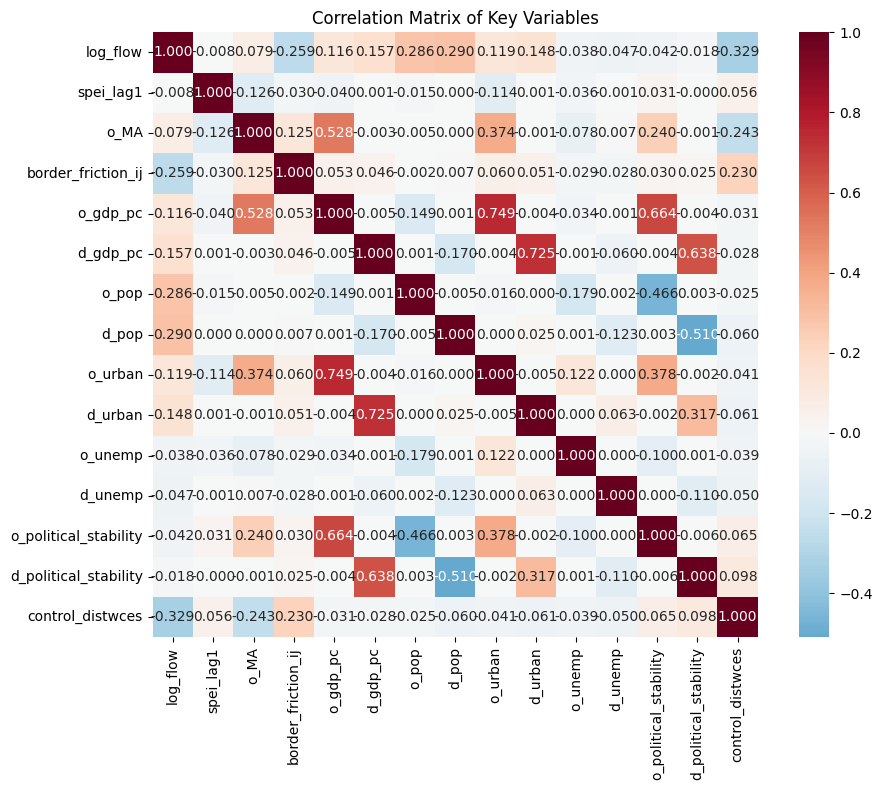

=== 多重共线性检查 ===
高相关性: o_gdp_pc - o_urban: 0.749
高相关性: d_gdp_pc - d_urban: 0.725


In [37]:
# 相关性矩阵 (论文Figure)
corr_vars = ['log_flow', 'spei_lag1', 'o_MA', 'border_friction_ij', 
             'o_gdp_pc', 'd_gdp_pc','o_pop', 'd_pop','o_urban', 'd_urban',
             'o_unemp', 'd_unemp','o_political_stability', 'd_political_stability',
             'control_distwces'
             ]
correlation_matrix = migration_df_improved[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f')
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()


# 检查多重共线性
print("=== 多重共线性检查 ===")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if corr_val > 0.7:
            high_corr.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

if high_corr:
    for var1, var2, corr in high_corr:
        print(f"高相关性: {var1} - {var2}: {corr:.3f}")
else:
    print("无严重多重共线性问题")

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 选择相关性计算的变量
corr_vars = [
    'log_flow', 'spei_lag1', 'o_MA', 'border_friction_ij', 
    'o_gdp_pc', 'd_gdp_pc', 'o_pop', 'd_pop', 'o_urban', 'd_urban',
    'o_unemp', 'd_unemp', 'o_political_stability', 'd_political_stability',
    'control_distwces'
]

# 计算相关性矩阵
correlation_matrix = migration_df_improved[corr_vars].corr()

# 输出相关性矩阵数值
print("=== 相关性矩阵 ===")
print(correlation_matrix.round(3))

=== 相关性矩阵 ===
                       log_flow  spei_lag1   o_MA  border_friction_ij  \
log_flow                  1.000     -0.008  0.079              -0.259   
spei_lag1                -0.008      1.000 -0.126              -0.030   
o_MA                      0.079     -0.126  1.000               0.125   
border_friction_ij       -0.259     -0.030  0.125               1.000   
o_gdp_pc                  0.116     -0.040  0.528               0.053   
d_gdp_pc                  0.157      0.001 -0.003               0.046   
o_pop                     0.286     -0.015 -0.005              -0.002   
d_pop                     0.290      0.000  0.000               0.007   
o_urban                   0.119     -0.114  0.374               0.060   
d_urban                   0.148      0.001 -0.001               0.051   
o_unemp                  -0.038     -0.036 -0.078              -0.029   
d_unemp                  -0.047     -0.001  0.007              -0.028   
o_political_stability    -0.042      

#### 5. 时间趋势检查 (论文Figure)

C:\Users\cmy\AppData\Local\Temp\ipykernel_32976\3768129910.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


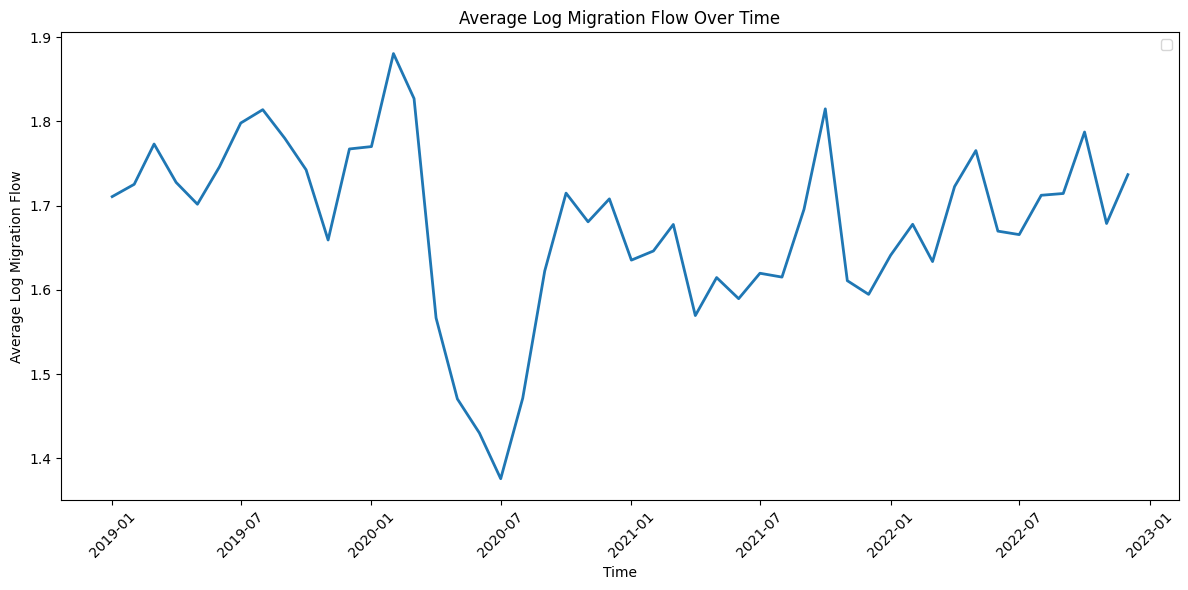

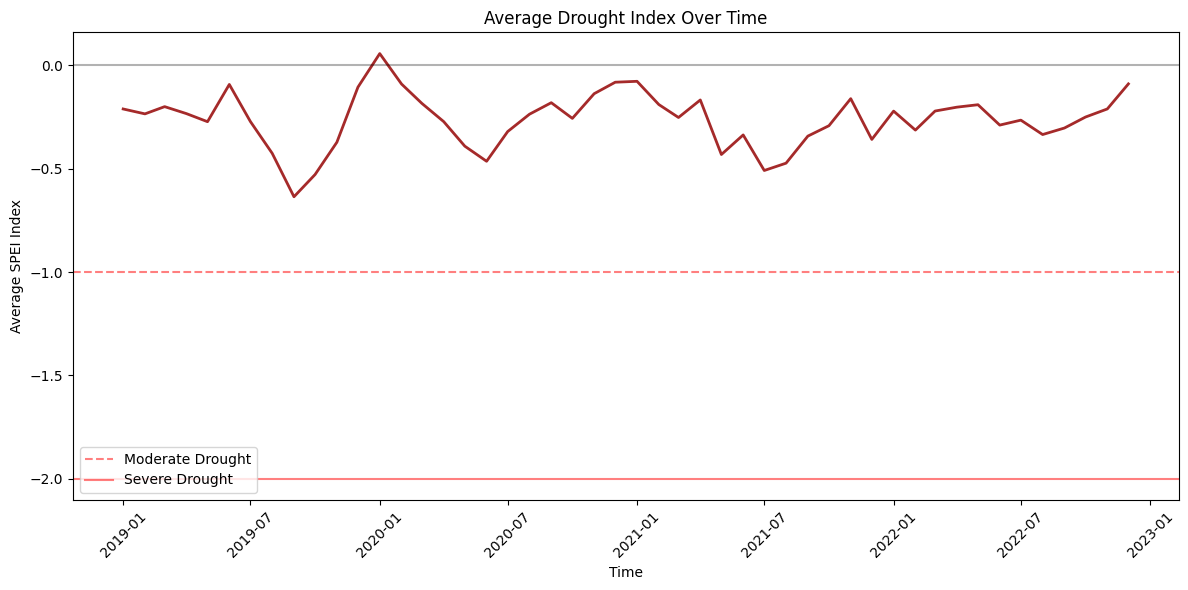

In [38]:
# 移民流时间趋势
monthly_flow = migration_df_improved.groupby('migration_date')['log_flow'].mean().reset_index()
monthly_flow['migration_date'] = pd.to_datetime(monthly_flow['migration_date'])

plt.figure(figsize=(12, 6))
plt.plot(monthly_flow['migration_date'], monthly_flow['log_flow'], linewidth=2)
plt.title('Average Log Migration Flow Over Time')
plt.xlabel('Time')
plt.ylabel('Average Log Migration Flow')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 干旱时间趋势
monthly_drought = migration_df_improved.groupby('migration_date')['spei_lag1'].mean().reset_index()
monthly_drought['migration_date'] = pd.to_datetime(monthly_drought['migration_date'])

plt.figure(figsize=(12, 6))
plt.plot(monthly_drought['migration_date'], monthly_drought['spei_lag1'], linewidth=2, color='brown')
plt.title('Average Drought Index Over Time')
plt.xlabel('Time')
plt.ylabel('Average SPEI Index')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axhline(y=-1, color='red', linestyle='--', alpha=0.5, label='Moderate Drought')
plt.axhline(y=-2, color='red', linestyle='-', alpha=0.5, label='Severe Drought')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 6. 地理分布检查 (论文Table/Figure)

In [39]:
# 按起源国汇总
origin_summary = migration_df_improved.groupby('origin_iso3').agg({
    'log_flow': 'mean',
    'spei_lag1': 'mean',
    'o_MA': 'mean',
    'flow': 'sum'
}).round(3)
origin_summary = origin_summary.sort_values('flow', ascending=False)

print("=== 主要起源国 (前20) ===")
print(origin_summary.head(20))

# 按目的国汇总
dest_summary = migration_df_improved.groupby('destination_iso3').agg({
    'log_flow': 'mean',
    'd_gdp_pc': 'mean',
    'flow': 'sum'
}).round(3)
dest_summary = dest_summary.sort_values('flow', ascending=False)

print("\n=== 主要目的国 (前20) ===")
print(dest_summary.head(20))

=== 主要起源国 (前20) ===
             log_flow  spei_lag1    o_MA     flow
origin_iso3                                      
IND             4.179      0.287  18.280  8883022
SAU             2.922     -0.875  18.503  7293174
USA             4.454      0.117  17.611  3846142
VEN             1.890     -0.139  18.211  3790068
PHL             2.922      0.150  18.588  3317166
BGD             2.686     -0.124  18.687  3192106
MYS             2.355      0.113  18.540  3101151
UKR             2.528     -0.417  19.133  3025450
ARE             2.779     -0.708  18.690  2952510
PAK             2.594      0.054  18.635  2920183
MEX             2.158     -0.376  18.572  2807881
COL             2.109      0.005  18.117  2425018
EGY             2.651     -0.874  18.892  2335777
THA             2.662     -0.040  18.624  2086069
VNM             2.467     -0.126  18.707  2032834
GBR             3.550     -0.024  19.852  2012313
NPL             2.046      0.111  18.807  1916693
RUS             3.121     -0.0

#### 7. 干旱分布和移民关系初步检查

=== Average Migration Flow by Drought Intensity ===
                      mean   count
drought_category                  
Extreme Drought   1.463018   28533
Severe Drought    1.689929   77137
Moderate Drought  1.710957  162900
Mild Drought      1.690435  231893
Non-Drought       1.674589  819323


C:\Users\cmy\AppData\Local\Temp\ipykernel_32976\3234459795.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  drought_flow = migration_df_improved.groupby('drought_category')['log_flow'].agg(['mean', 'count'])


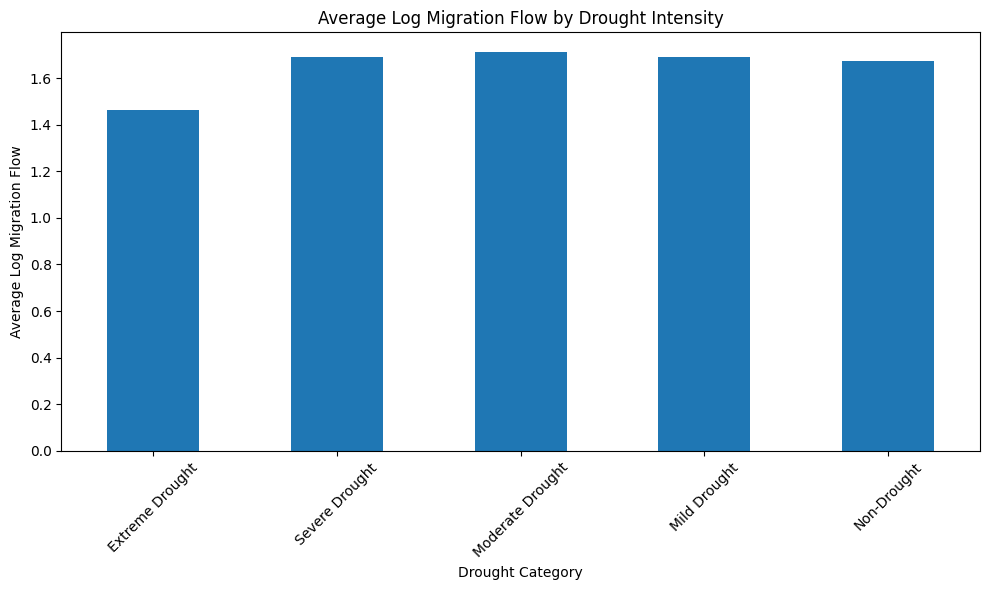

In [40]:
# 创建干旱强度分组
# 按照McKee et al. (1993) 和 Paulo et al. (2012)的标准
migration_df_improved['drought_category'] = pd.cut(
    migration_df_improved['spei_lag1'], 
    bins=[-np.inf, -2.0, -1.5, -1.0, -0.5, np.inf],
    labels=['Extreme Drought', 'Severe Drought', 'Moderate Drought', 
            'Mild Drought', 'Non-Drought']
)

# 按干旱强度分组的平均移民流
drought_flow = migration_df_improved.groupby('drought_category')['log_flow'].agg(['mean', 'count'])
print("=== Average Migration Flow by Drought Intensity ===")
print(drought_flow)

# 可视化
plt.figure(figsize=(10, 6))
drought_flow['mean'].plot(kind='bar')
plt.title('Average Log Migration Flow by Drought Intensity')
plt.xlabel('Drought Category')
plt.ylabel('Average Log Migration Flow')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 8. 数据完整性最终检查

In [41]:
print("=== 最终数据检查 ===")
print(f"最终数据集大小: {migration_df_improved.shape}")
print(f"变量数量: {migration_df_improved.shape[1]}")
print(f"观测数量: {migration_df_improved.shape[0]:,}")
print(f"完整观测数量: {migration_df_improved.dropna().shape[0]:,}")
print(f"数据完整率: {migration_df_improved.dropna().shape[0]/migration_df_improved.shape[0]*100:.2f}%")


=== 最终数据检查 ===
最终数据集大小: (1319786, 36)
变量数量: 36
观测数量: 1,319,786
完整观测数量: 1,319,786
数据完整率: 100.00%


### 输出

In [42]:
migration_df_improved

,origin_iso3,destination_iso3,migration_date,year,month,flow,log_flow,o_spei,spei_date,spei_lag1,...,d_gdp_pc_was_missing,o_unemp_was_missing,d_unemp_was_missing,o_pop_was_missing,d_pop_was_missing,o_urban_was_missing,d_urban_was_missing,o_political_stability_was_missing,d_political_stability_was_missing,drought_category
8640,ARE,AND,2019-01-01,2019,1,0,0.000000,0.013769,2019-01-16,0.345254,...,0,0,1,0,0,0,0,0,1,Non-Drought
8641,ARE,AND,2019-02-01,2019,2,12,2.564949,-0.017917,2019-02-15,0.013769,...,0,0,1,0,0,0,0,0,1,Non-Drought
8642,ARE,AND,2019-03-01,2019,3,0,0.000000,0.490999,2019-03-16,-0.017917,...,0,0,1,0,0,0,0,0,1,Non-Drought
8643,ARE,AND,2019-04-01,2019,4,1,0.693147,0.797000,2019-04-16,0.490999,...,0,0,1,0,0,0,0,0,1,Non-Drought
8644,ARE,AND,2019-05-01,2019,5,3,1.386294,0.580897,2019-05-16,0.797000,...,0,0,1,0,0,0,0,0,1,Non-Drought
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563149,ZWE,ZMB,2022-08-01,2022,8,138,4.934474,0.326137,2022-08-16,0.494725,...,0,0,0,0,0,0,0,0,0,Non-Drought
1563150,ZWE,ZMB,2022-09-01,2022,9,162,5.093750,-0.502948,2022-09-16,0.326137,...,0,0,0,0,0,0,0,0,0,Non-Drought
1563151,ZWE,ZMB,2022-10-01,2022,10,149,5.010635,-0.593602,2022-10-16,-0.502948,...,0,0,0,0,0,0,0,0,0,Mild Drought
1563152,ZWE,ZMB,2022-11-01,2022,11,104,4.653960,-0.331173,2022-11-16,-0.593602,...,0,0,0,0,0,0,0,0,0,Mild Drought


In [43]:
# # === 保存清理后的数据 ===
# output_improved_path = '../data/processed/merged_dataset_cleaned.csv'
# migration_df_improved.to_csv(output_improved_path, index=False)
# print(f"填补缺失值并完成清理的数据已保存到: {output_improved_path}")

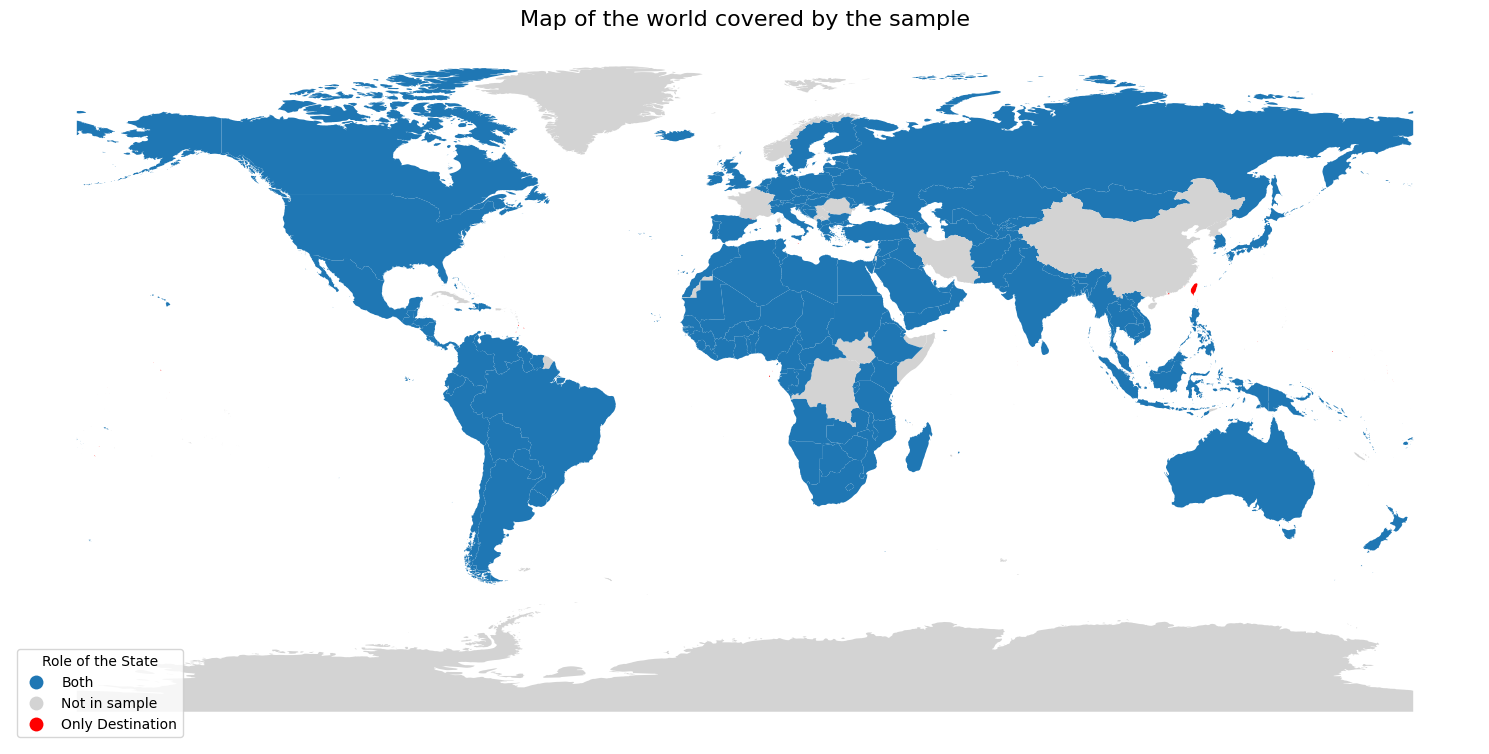

In [44]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 加载世界地图数据（使用下载的 Natural Earth 数据）
world_map_path = '../data/raw/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp'
world = gpd.read_file(world_map_path)

# 提取样本国家信息
origins = set(migration_df_improved['origin_iso3'].dropna())
destinations = set(migration_df_improved['destination_iso3'].dropna())

# 标记国家角色
world['status'] = 'Not in sample'
world.loc[world['ISO_A3'].isin(origins - destinations), 'status'] = 'Only Origin'
world.loc[world['ISO_A3'].isin(destinations - origins), 'status'] = 'Only Destination'
world.loc[world['ISO_A3'].isin(origins & destinations), 'status'] = 'Both'

# 定义颜色映射
color_map = ListedColormap(['#1f77b4', 'orange', 'lightgrey', 'red'])
status_order = ['Not in sample', 'Only Origin', 'Only Destination', 'Both']

# 绘制地图
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world.plot(column='status', ax=ax, cmap=color_map, legend=True, 
           legend_kwds={'title': 'Role of the State', 'loc': 'lower left', 'fontsize': 10})
ax.set_title('Map of the world covered by the sample', fontsize=16)
ax.axis('off')

# 显示地图
plt.tight_layout()
plt.show()

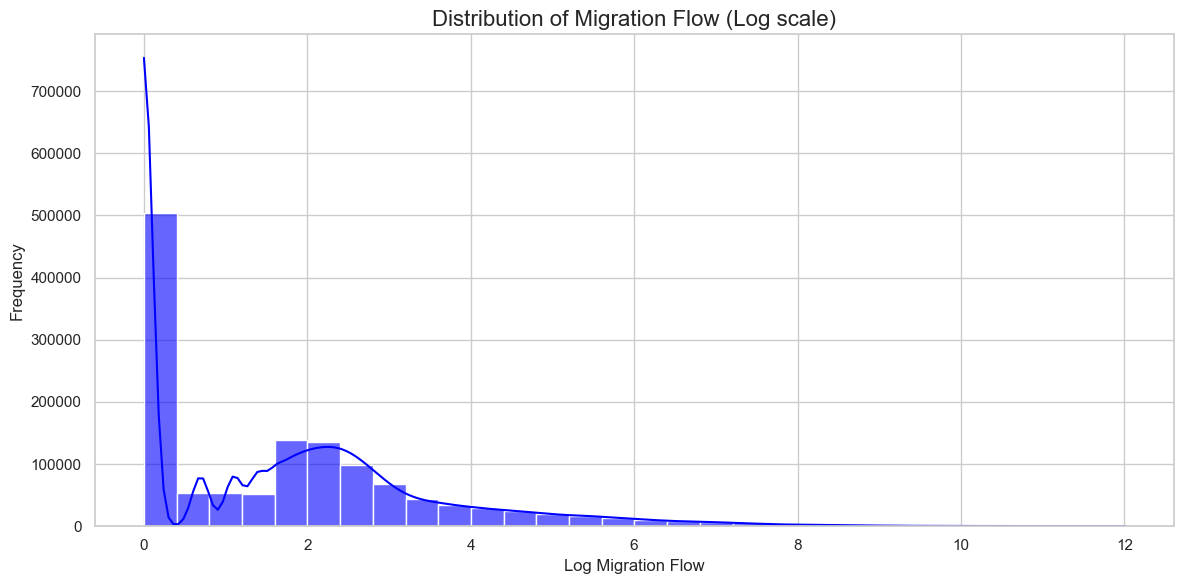

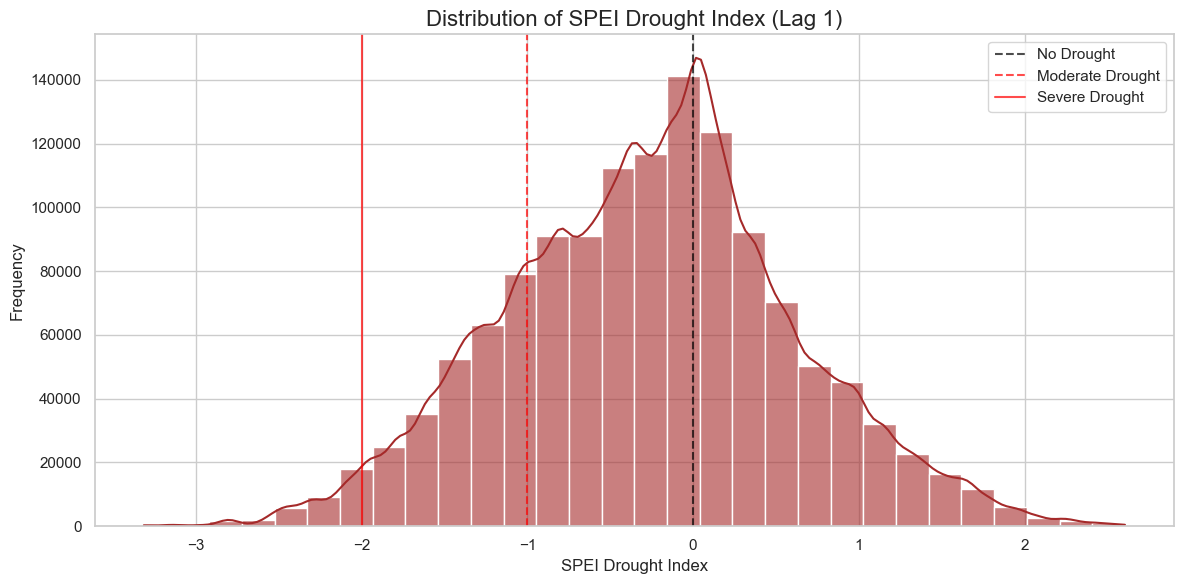

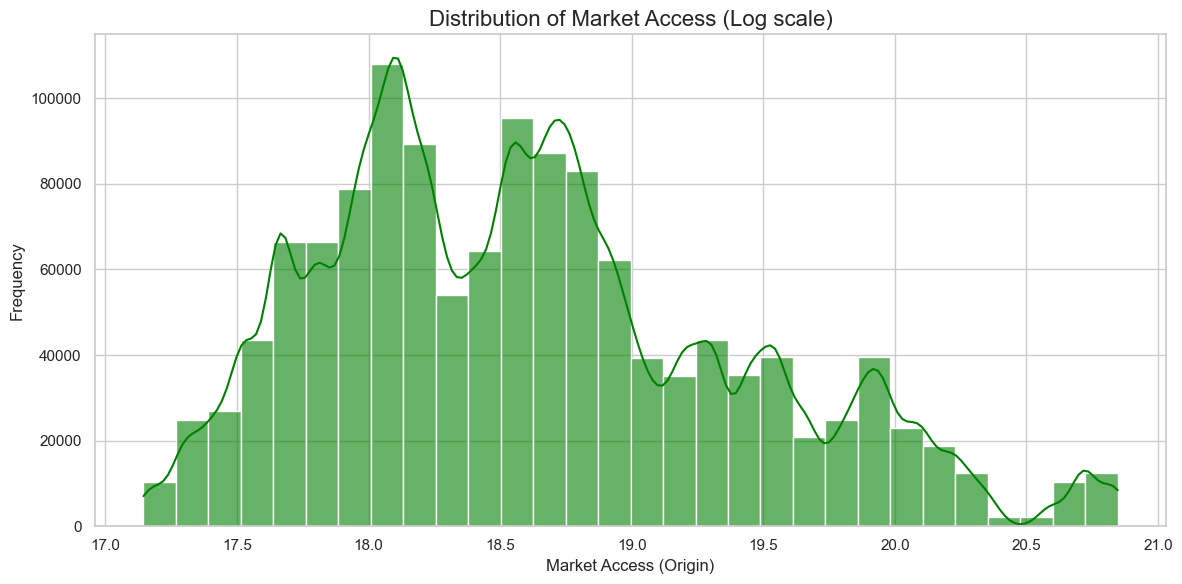

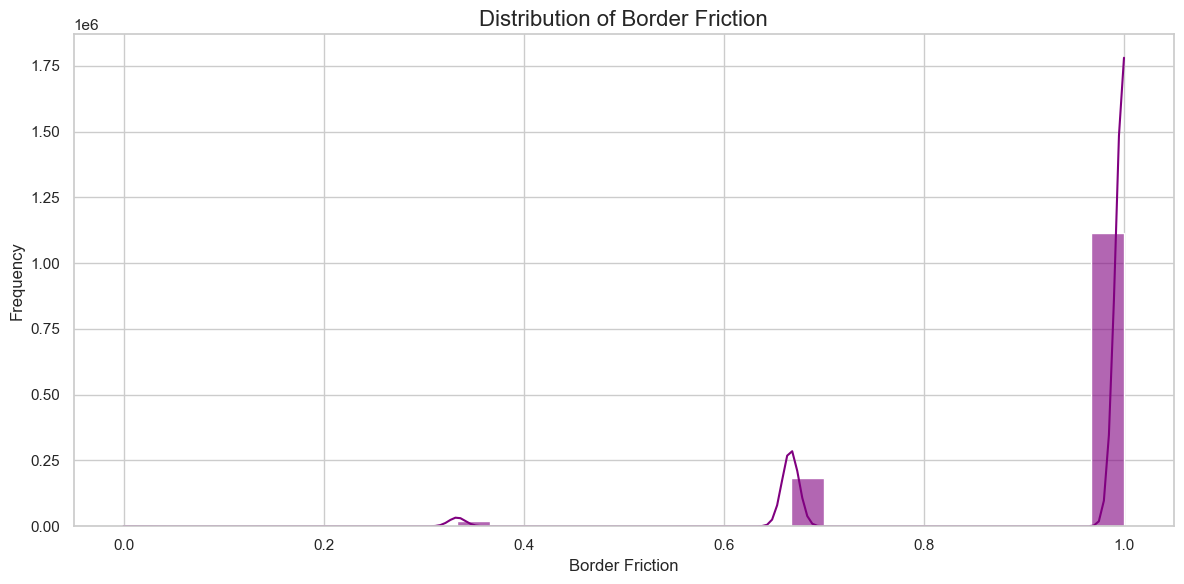

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置全局样式
sns.set(style="whitegrid")

# 1. 对数移民流的直方图和密度图
plt.figure(figsize=(12, 6))
sns.histplot(migration_df_improved['log_flow'], kde=True, bins=30, color='blue', alpha=0.6)
plt.title('Distribution of Migration Flow (Log scale)', fontsize=16)
plt.xlabel('Log Migration Flow', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# 2. SPEI干旱指数的分布
plt.figure(figsize=(12, 6))
sns.histplot(migration_df_improved['spei_lag1'], kde=True, bins=30, color='brown', alpha=0.6)
plt.title('Distribution of SPEI Drought Index (Lag 1)', fontsize=16)
plt.xlabel('SPEI Drought Index', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7, label='No Drought')
plt.axvline(x=-1, color='red', linestyle='--', alpha=0.7, label='Moderate Drought')
plt.axvline(x=-2, color='red', linestyle='-', alpha=0.7, label='Severe Drought')
plt.legend()
plt.tight_layout()
plt.show()

# 3. 市场准入的分布
plt.figure(figsize=(12, 6))
sns.histplot(migration_df_improved['o_MA'], kde=True, bins=30, color='green', alpha=0.6)
plt.title('Distribution of Market Access (Log scale)', fontsize=16)
plt.xlabel('Market Access (Origin)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# 4. 边境摩擦的分布
plt.figure(figsize=(12, 6))
sns.histplot(migration_df_improved['border_friction_ij'], kde=True, bins=30, color='purple', alpha=0.6)
plt.title('Distribution of Border Friction', fontsize=16)
plt.xlabel('Border Friction', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

#### 不同SPEI条件下的flow

以下是实现您描述的分组均值趋势分析的代码。代码将 MA（市场准入）或 BF（边境摩擦）按中位数分组，并绘制不同 SPEI 条件下的平均 log_flow 的柱状图或折线图。

C:\Users\cmy\AppData\Local\Temp\ipykernel_32976\3781986218.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = migration_df_improved.groupby(['MA_group', 'SPEI_category'])['log_flow'].mean().reset_index()


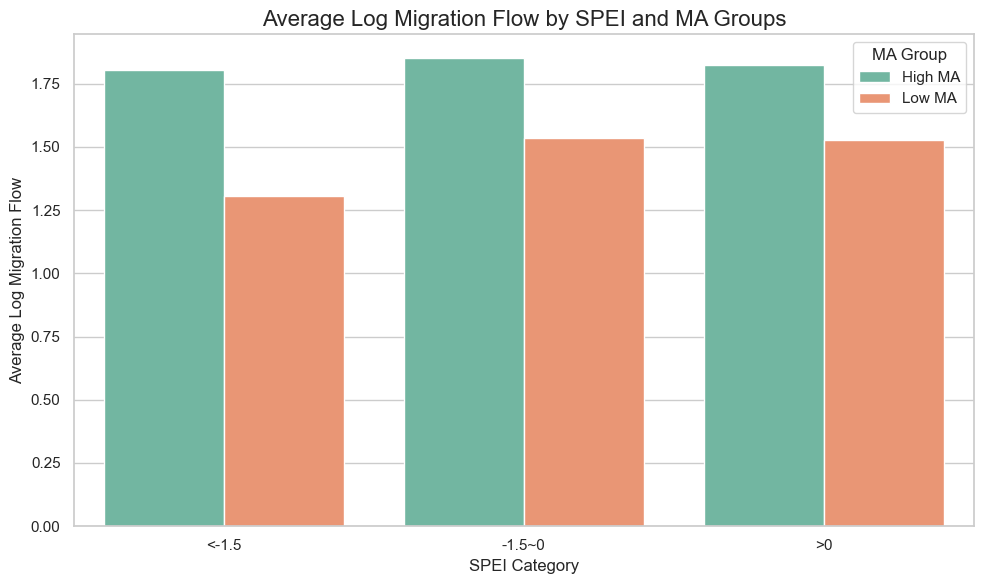

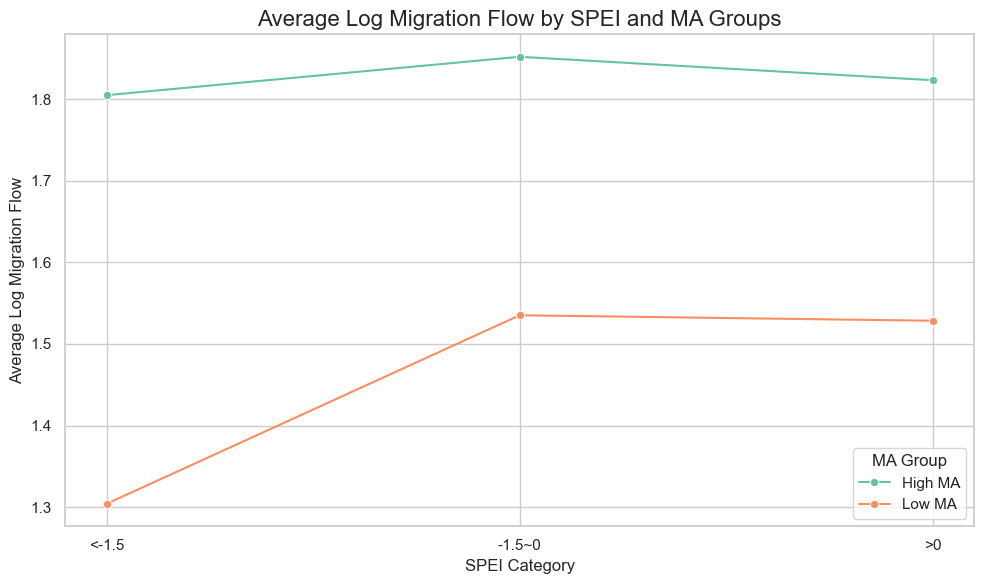

C:\Users\cmy\AppData\Local\Temp\ipykernel_32976\3781986218.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_BF = migration_df_improved.groupby(['BF_group', 'SPEI_category'])['log_flow'].mean().reset_index()


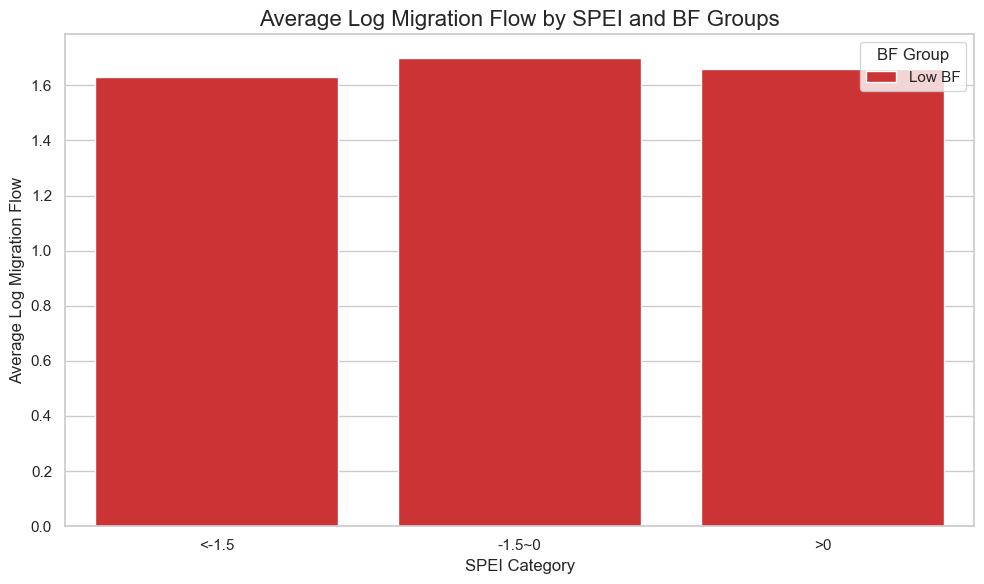

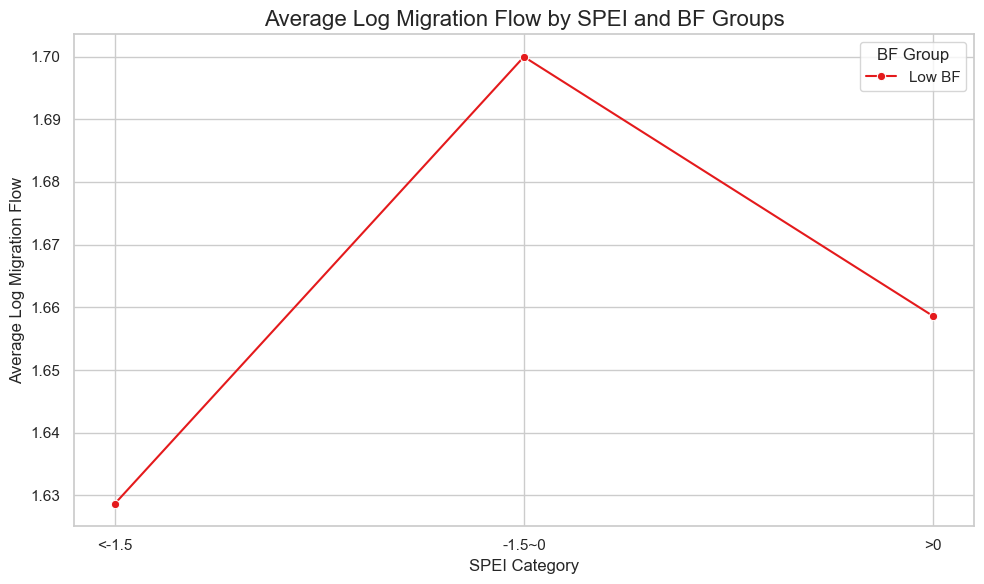

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 确保全局样式一致
sns.set(style="whitegrid")

# 1. 按中位数将 MA 分为高组和低组
median_MA = migration_df_improved['o_MA'].median()
migration_df_improved['MA_group'] = migration_df_improved['o_MA'].apply(lambda x: 'High MA' if x > median_MA else 'Low MA')

# 2. SPEI 分档
migration_df_improved['SPEI_category'] = pd.cut(
    migration_df_improved['spei_lag1'], 
    bins=[-float('inf'), -1.5, 0, float('inf')], 
    labels=['<-1.5', '-1.5~0', '>0']
)

# 3. 计算每组的平均 log_flow
grouped_data = migration_df_improved.groupby(['MA_group', 'SPEI_category'])['log_flow'].mean().reset_index()

# 4. 绘制柱状图
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_data, x='SPEI_category', y='log_flow', hue='MA_group', palette='Set2')
plt.title('Average Log Migration Flow by SPEI and MA Groups', fontsize=16)
plt.xlabel('SPEI Category', fontsize=12)
plt.ylabel('Average Log Migration Flow', fontsize=12)
plt.legend(title='MA Group')
plt.tight_layout()
plt.show()

# 5. 如果需要折线图
plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_data, x='SPEI_category', y='log_flow', hue='MA_group', marker='o', palette='Set2')
plt.title('Average Log Migration Flow by SPEI and MA Groups', fontsize=16)
plt.xlabel('SPEI Category', fontsize=12)
plt.ylabel('Average Log Migration Flow', fontsize=12)
plt.legend(title='MA Group')
plt.tight_layout()
plt.show()

# 6. 如果需要对 BF（边境摩擦）进行类似分析
median_BF = migration_df_improved['border_friction_ij'].median()
migration_df_improved['BF_group'] = migration_df_improved['border_friction_ij'].apply(lambda x: 'High BF' if x > median_BF else 'Low BF')

# 7. 计算 BF 分组的平均 log_flow
grouped_data_BF = migration_df_improved.groupby(['BF_group', 'SPEI_category'])['log_flow'].mean().reset_index()

# 8. 绘制 BF 分组的柱状图
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_data_BF, x='SPEI_category', y='log_flow', hue='BF_group', palette='Set1')
plt.title('Average Log Migration Flow by SPEI and BF Groups', fontsize=16)
plt.xlabel('SPEI Category', fontsize=12)
plt.ylabel('Average Log Migration Flow', fontsize=12)
plt.legend(title='BF Group')
plt.tight_layout()
plt.show()

# 9. 绘制 BF 分组的折线图
plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_data_BF, x='SPEI_category', y='log_flow', hue='BF_group', marker='o', palette='Set1')
plt.title('Average Log Migration Flow by SPEI and BF Groups', fontsize=16)
plt.xlabel('SPEI Category', fontsize=12)
plt.ylabel('Average Log Migration Flow', fontsize=12)
plt.legend(title='BF Group')
plt.tight_layout()
plt.show()

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置全局样式
sns.set(style="whitegrid")

# 1. 选择控制变量
control_vars = [
    'o_gdp_pc', 'o_pop', 'o_urban', 'o_unemp', 'o_political_stability',
    'd_gdp_pc', 'd_pop', 'd_urban', 'd_unemp', 'd_political_stability',
    'control_distwces'
]

# 2. 生成描述性统计表
desc_stats = migration_df_improved[control_vars].describe().T
desc_stats['median'] = migration_df_improved[control_vars].median()  # 添加中位数
desc_stats = desc_stats[['mean', 'std', 'min', 'median', 'max']]  # 选择需要的列

# 输出描述性统计表
print("=== 描述性统计表 ===")
print(desc_stats)


=== 描述性统计表 ===
                            mean        std        min     median         max
o_gdp_pc                8.645500   1.426507   5.347146   8.533776   11.812777
o_pop                  16.155028   1.654880  11.533179  16.160612   21.077735
o_urban                59.607019  22.187376  13.250000  59.600000  100.000000
o_unemp                 7.673531   5.825244   0.100000   5.607000   34.153000
o_political_stability  -0.189119   0.924818  -2.776898  -0.176798    1.619806
d_gdp_pc                8.718212   1.425158   5.347146   8.626604   11.812777
d_pop                  15.888206   1.861803  11.244706  16.069952   21.077735
d_urban                59.850991  23.042625  13.250000  59.600000  100.000000
d_unemp                 7.520809   5.741730   0.100000   5.542000   34.153000
d_political_stability  -0.108460   0.935300  -2.776898  -0.091492    1.619806
control_distwces        8.717069   0.776086   4.525563   8.883121    9.892441
